In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/colorado_river_basin_water_conflict_table.csv")

In [4]:
df.shape

(268, 48)

In [6]:
df.dtypes

Event                                             int64
Search Source                                    object
Newspaper                                        object
Article Title                                    object
Duplicate                                        object
Report Date                                      object
Report Year                                     float64
Event Date                                       object
Event Day                                       float64
Event Month                                     float64
Event Year                                      float64
Conflict Present                                 object
Crisis Present                                   object
Basin                                            object
HUC6                                             object
HUC2                                             object
Place                                            object
County                                          

In [8]:
df.columns

Index(['Event', 'Search Source', 'Newspaper', 'Article Title', 'Duplicate',
       'Report Date', 'Report Year', 'Event Date', 'Event Day', 'Event Month',
       'Event Year', 'Conflict Present', 'Crisis Present', 'Basin', 'HUC6',
       'HUC2', 'Place', 'County', 'County FIPS', 'State', 'State FIPS',
       'Urban or Rural', 'Issue Type', 'Event Summary', 'Stakeholders',
       'Intensity Value', 'Comments', 'Related Observation Themes',
       'Article Text Search - water quality',
       'Article Text Search - invasive species',
       'Article Text Search - conservation', 'Article Text Search - drought',
       'Article Text Search - flood',
       'Article Text Search - ground water depletion',
       'Article Text Search - depletion',
       'Article Text Search - infrastructure',
       'Article Text Search - fish passage',
       'Article Text Search - instream water rights',
       'Article Text Search - water rights',
       'Article Text Search - intergovernmental',
       '

In [16]:
df["Issue Type"].nunique

<bound method IndexOpsMixin.nunique of 0                            Water rights more generally
1                            Water rights more generally
2                                  Instream water rights
3                            Water rights more generally
4                               Intergovernmental issues
                             ...                        
263                          Water rights more generally
264    Drought; Water quality; Water rights more gene...
265                             Intergovernmental issues
266                                         Conservation
267                 Conservation; Ground water depletion
Name: Issue Type, Length: 268, dtype: object>

In [15]:
df["State"].nunique

<bound method IndexOpsMixin.nunique of 0          CO
1          CO
2          UT
3         NaN
4         NaN
        ...  
263        CO
264        CO
265    AZ; CA
266        AZ
267        AZ
Name: State, Length: 268, dtype: object>

In [5]:
import numpy as np
import pandas as pd 

# Example series
s = pd.Series(['California; Nevada', 'Arizona', np.nan, 'Nevada; Utah'])
s

0    California; Nevada
1               Arizona
2                   NaN
3          Nevada; Utah
dtype: object

In [17]:
# CELL 2
# str accessor (doesn't do anything by itself)
s.str

In [18]:
# CELL 3
# Use str accessor with additional methods to perform string operations
s.str.split(';')

0    [California,  Nevada]
1                [Arizona]
2                      NaN
3          [Nevada,  Utah]
dtype: object

In [19]:
# CELL 4
s.str.split(';').explode()

0    California
0        Nevada
1       Arizona
2           NaN
3        Nevada
3          Utah
dtype: object

In [28]:
df["State"].value_counts()

State
AZ                            66
CO                            34
UT                            27
NV                            10
CA                             7
NM                             6
AZ; CA                         4
AZ; UT                         3
AZ; CA; CO; NV; NM; UT; WY     3
AZ; NV                         2
NV; AZ                         2
CO; AZ                         2
CO; UT; WY; NM                 2
AZ; NM                         1
CA; NV; AZ                     1
WY; UT; CO                     1
UT; CO; WY                     1
CO; WY                         1
AZ; CA; NV                     1
UT; AZ                         1
AZ; CO; NM; UT                 1
OH; UT                         1
TX                             1
Name: count, dtype: int64

In [32]:
df["State"].str.split('; ').explode()

0       CO
1       CO
2       UT
3      NaN
4      NaN
      ... 
264     CO
265     AZ
265     CA
266     AZ
267     AZ
Name: State, Length: 320, dtype: object

In [31]:
df["State"].str.split('; ').explode().value_counts()

State
AZ    87
CO    45
UT    40
NV    19
CA    16
NM    13
WY     8
OH     1
TX     1
Name: count, dtype: int64

In [ ]:
# Examine State Codes

In [37]:
df.loc[df["State"].notna(), "State"]

0          CO
1          CO
2          UT
5          AZ
11     OH; UT
        ...  
263        CO
264        CO
265    AZ; CA
266        AZ
267        AZ
Name: State, Length: 178, dtype: object

In [ ]:
# Find which states are reported in the dataset as having water conflicts

In [35]:
df["State"].notna().value_counts()

State
True     178
False     90
Name: count, dtype: int64

In [36]:
df["Conflict Present"].value_counts()

Conflict Present
Y    145
N    107
Name: count, dtype: int64

In [42]:
conflicts = df[df["Conflict Present"] == "Y"]

In [44]:
conflicts["State"].str.split('; ').explode().value_counts()

State
AZ    45
UT    29
CO    22
NV    12
NM    10
CA     7
WY     6
OH     1
Name: count, dtype: int64

In [57]:
new_df = df[["State", "Conflict Present"]]
new_df = new_df.loc[new_df["State"].notna()]
new_df = new_df[new_df["Conflict Present"] == "Y"]
new_df

,State,Conflict Present
0,CO,Y
1,CO,Y
5,AZ,Y
11,OH; UT,Y
12,UT,Y
...,...,...
255,UT,Y
257,AZ,Y
258,UT,Y
262,AZ,Y


In [66]:
df.loc[df["Conflict Present"] == "Y", "State"].str.split("; ").explode().unique()

array(['CO', nan, 'AZ', 'OH', 'UT', 'CA', 'NV', 'WY', 'NM'], dtype=object)

In [ ]:
# Find unique state codes

In [72]:
new_df["State"].str.split("; ").explode().unique()

array(['CO', 'AZ', 'OH', 'UT', 'CA', 'NV', 'WY', 'NM'], dtype=object)

In [90]:
states_unique = (
    df.loc[df["Conflict Present"] == "Y", "State"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts(dropna=False)
)
states_unique

State
NaN    47
AZ     45
UT     29
CO     22
NV     12
NM     10
CA      7
WY      6
OH      1
Name: count, dtype: int64

<Axes: xlabel='State'>

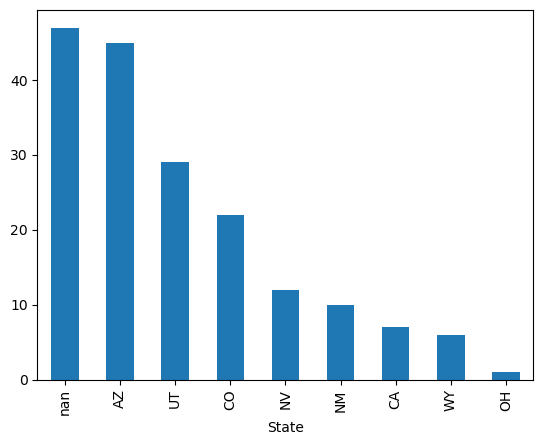

In [91]:
states_unique.plot(kind = 'bar')